In [18]:
# %% [markdown]
# ## Cell 01 — Imports

# %%
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json
import os
import warnings

warnings.filterwarnings("ignore")

print("Libraries loaded successfully.")
print(f"NetworkX version: {nx.__version__}")

Libraries loaded successfully.
NetworkX version: 3.6.1


In [19]:
# %% [markdown]
# ## Cell 02 — Load Notebook 01 Artifacts
#
# We load:
# - The cleaned classified dataset (clause_text, clause_type, label)
# - The label class names saved by the Legal-BERT pipeline
#
# No model retraining. No preprocessing. Read-only consumption of NB01 outputs.

# %%
ARTIFACTS_DIR = "legal_bert_classifier"

# Load cleaned dataset
df = pd.read_csv(os.path.join(ARTIFACTS_DIR, "cuad_classified_clean.csv"))

# Load label class names
label_classes = np.load(
    os.path.join(ARTIFACTS_DIR, "label_classes.npy"),
    allow_pickle=True
)

print(f"Dataset loaded:  {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Clause types:    {len(label_classes)}")
print(f"\nLabel classes:\n{list(label_classes)}")
print(f"\nSample rows:")
df.head(3)

Dataset loaded:  6226 rows, 3 columns
Clause types:    8

Label classes:
['change_of_control', 'confidentiality_non_compete', 'governing_law', 'intellectual_property', 'limitation_of_liability', 'payment', 'termination', 'warranties']

Sample rows:


,clause_text,clause_type,label
0,This Agreement is to be construed according to...,governing_law,2
1,Distributor further agrees that it will not in...,confidentiality_non_compete,1
2,Term of the Agreement and for a period of e...,confidentiality_non_compete,1


In [20]:
# %% [markdown]
# ## Cell 03 — Ontology Schema Definition
#
# We define four node categories:
#
# | Node Category     | Description                                      |
# |-------------------|--------------------------------------------------|
# | ClauseType        | The 10 legal clause categories from Legal-BERT   |
# | LegalConcept      | Abstract legal principles (e.g. obligation)      |
# | RiskDomain        | Risk areas a clause may expose a party to        |
# | ContractElement   | Structural contract components                   |
#
# Relationships:
# affects, governs, depends_on, increases_risk,
# mitigates_risk, triggers, relates_to

# %%
# ── Node definitions ──────────────────────────────────────────────────────────

CLAUSE_TYPES = list(label_classes)

LEGAL_CONCEPTS = [
    "obligation",
    "right",
    "liability",
    "enforceability",
    "consent",
    "consideration",
    "breach",
    "remedy",
    "ownership",
    "confidentiality",
    "exclusivity",
    "jurisdiction",
    "damages",
    "indemnity",
    "warranty",
]

RISK_DOMAINS = [
    "financial_risk",
    "legal_risk",
    "operational_risk",
    "reputational_risk",
    "compliance_risk",
    "strategic_risk",
]

CONTRACT_ELEMENTS = [
    "contract_duration",
    "party_obligations",
    "dispute_mechanism",
    "exit_provisions",
    "ip_provisions",
    "payment_terms",
    "governing_framework",
    "liability_cap",
    "performance_standards",
]

print(f"Clause types defined:      {len(CLAUSE_TYPES)}")
print(f"Legal concepts defined:    {len(LEGAL_CONCEPTS)}")
print(f"Risk domains defined:      {len(RISK_DOMAINS)}")
print(f"Contract elements defined: {len(CONTRACT_ELEMENTS)}")

Clause types defined:      8
Legal concepts defined:    15
Risk domains defined:      6
Contract elements defined: 9


In [21]:
# %% [markdown]
# ## Cell 04 — Semantic Relationship Maps
#
# Each clause type is mapped to:
# - legal concepts it instantiates
# - risk domains it activates
# - contract elements it belongs to
# - dependencies on other clause types

# %%
# Clause → Legal Concepts
CLAUSE_TO_CONCEPTS = {
    "termination":               ["obligation", "breach", "remedy", "enforceability"],
    "governing_law":             ["jurisdiction", "enforceability"],
    "limitation_of_liability":   ["liability", "damages", "remedy"],
    "intellectual_property":     ["ownership", "right", "consent"],
    "confidentiality_non_compete": ["confidentiality", "obligation", "exclusivity"],
    "payment":                   ["obligation", "consideration", "damages"],
    "indemnification":           ["indemnity", "liability", "remedy"],
    "warranties":                ["warranty", "obligation", "enforceability"],
    "change_of_control":         ["consent", "right", "enforceability"],
    "dispute_resolution":        ["remedy", "jurisdiction", "enforceability"],
}

# Clause → Risk Domains
CLAUSE_TO_RISKS = {
    "termination":               ["legal_risk", "operational_risk"],
    "governing_law":             ["legal_risk", "compliance_risk"],
    "limitation_of_liability":   ["financial_risk", "legal_risk"],
    "intellectual_property":     ["strategic_risk", "legal_risk"],
    "confidentiality_non_compete": ["reputational_risk", "legal_risk", "strategic_risk"],
    "payment":                   ["financial_risk", "operational_risk"],
    "indemnification":           ["financial_risk", "legal_risk"],
    "warranties":                ["legal_risk", "operational_risk", "compliance_risk"],
    "change_of_control":         ["strategic_risk", "financial_risk"],
    "dispute_resolution":        ["legal_risk", "financial_risk"],
}

# Clause → Contract Elements
CLAUSE_TO_ELEMENTS = {
    "termination":               ["exit_provisions", "contract_duration"],
    "governing_law":             ["governing_framework"],
    "limitation_of_liability":   ["liability_cap", "party_obligations"],
    "intellectual_property":     ["ip_provisions"],
    "confidentiality_non_compete": ["party_obligations"],
    "payment":                   ["payment_terms", "party_obligations"],
    "indemnification":           ["liability_cap", "party_obligations"],
    "warranties":                ["performance_standards", "party_obligations"],
    "change_of_control":         ["exit_provisions", "party_obligations"],
    "dispute_resolution":        ["dispute_mechanism"],
}

# Clause interdependencies (clause A depends_on clause B)
CLAUSE_DEPENDENCIES = [
    ("indemnification",         "limitation_of_liability"),
    ("dispute_resolution",      "governing_law"),
    ("termination",             "dispute_resolution"),
    ("payment",                 "termination"),
    ("change_of_control",       "termination"),
    ("warranties",              "indemnification"),
    ("intellectual_property",   "confidentiality_non_compete"),
]

print("Semantic relationship maps defined.")

Semantic relationship maps defined.


In [22]:
# %% [markdown]
# ## Cell 05 — Build Legal Ontology Graph
#
# Constructs a directed multigraph where:
# - Nodes carry a 'category' attribute for visual grouping
# - Edges carry a 'relation' attribute describing the semantic link

# %%
G = nx.DiGraph()

# ── Add nodes with category metadata ─────────────────────────────────────────
for node in CLAUSE_TYPES:
    G.add_node(node, category="ClauseType")

for node in LEGAL_CONCEPTS:
    G.add_node(node, category="LegalConcept")

for node in RISK_DOMAINS:
    G.add_node(node, category="RiskDomain")

for node in CONTRACT_ELEMENTS:
    G.add_node(node, category="ContractElement")

# ── Add edges ─────────────────────────────────────────────────────────────────
for clause, concepts in CLAUSE_TO_CONCEPTS.items():
    for concept in concepts:
        G.add_edge(clause, concept, relation="relates_to")

for clause, risks in CLAUSE_TO_RISKS.items():
    for risk in risks:
        G.add_edge(clause, risk, relation="increases_risk")

for clause, elements in CLAUSE_TO_ELEMENTS.items():
    for element in elements:
        G.add_edge(clause, element, relation="governs")

for src, tgt in CLAUSE_DEPENDENCIES:
    G.add_edge(src, tgt, relation="depends_on")

print(f"Ontology graph built successfully.")
print(f"  Nodes: {G.number_of_nodes()}")
print(f"  Edges: {G.number_of_edges()}")
print(f"\nNode category breakdown:")
from collections import Counter
cat_counts = Counter(nx.get_node_attributes(G, "category").values())
for cat, count in cat_counts.items():
    print(f"  {cat:<20s}  {count}")

Ontology graph built successfully.
  Nodes: 40
  Edges: 75

Node category breakdown:
  ClauseType            8
  LegalConcept          15
  RiskDomain            6
  ContractElement       9


In [23]:
# %% [markdown]
# ## Cell 06 — Symbolic Reasoning Functions
#
# Core query functions that implement symbolic reasoning over the ontology.
# These mirror how an expert legal reasoner would trace clause implications.

# %%
def get_legal_concepts(clause_type: str) -> list[str]:
    """Return all legal concepts associated with a clause type."""
    return [
        tgt for src, tgt, data in G.edges(data=True)
        if src == clause_type and data.get("relation") == "relates_to"
    ]


def get_risk_domains(clause_type: str) -> list[str]:
    """Return all risk domains activated by a clause type."""
    return [
        tgt for src, tgt, data in G.edges(data=True)
        if src == clause_type and data.get("relation") == "increases_risk"
    ]


def get_contract_elements(clause_type: str) -> list[str]:
    """Return contract elements governed by a clause type."""
    return [
        tgt for src, tgt, data in G.edges(data=True)
        if src == clause_type and data.get("relation") == "governs"
    ]


def get_dependencies(clause_type: str) -> list[str]:
    """Return clause types that this clause depends on."""
    return [
        tgt for src, tgt, data in G.edges(data=True)
        if src == clause_type and data.get("relation") == "depends_on"
    ]


def get_dependents(clause_type: str) -> list[str]:
    """Return clause types that depend on this clause (reverse lookup)."""
    return [
        src for src, tgt, data in G.edges(data=True)
        if tgt == clause_type and data.get("relation") == "depends_on"
    ]


def get_clauses_by_risk(risk_domain: str) -> list[str]:
    """Return all clause types that activate a given risk domain."""
    return [
        src for src, tgt, data in G.edges(data=True)
        if tgt == risk_domain and data.get("relation") == "increases_risk"
    ]


def compute_risk_score(clause_type: str) -> float:
    """
    Symbolic risk score = number of distinct risk domains activated.
    Normalised to [0, 1] over total available risk domains.
    """
    risks = get_risk_domains(clause_type)
    return round(len(risks) / len(RISK_DOMAINS), 4)


def get_semantic_neighbourhood(clause_type: str, depth: int = 2) -> set:
    """Return all nodes reachable from a clause type within `depth` hops."""
    return nx.descendants(G, clause_type) if depth >= 10 else {
        n for n in nx.single_source_shortest_path(G, clause_type, cutoff=depth)
    }


print("Symbolic reasoning functions defined.")

Symbolic reasoning functions defined.


In [24]:
# %% [markdown]
# ## Cell 07 — Smoke Test: Symbolic Queries on Two Clause Types

# %%
TEST_CLAUSES = ["indemnification", "intellectual_property"]

for ct in TEST_CLAUSES:
    print(f"\n{'='*55}")
    print(f"  Clause Type:        {ct}")
    print(f"  Legal Concepts:     {get_legal_concepts(ct)}")
    print(f"  Risk Domains:       {get_risk_domains(ct)}")
    print(f"  Contract Elements:  {get_contract_elements(ct)}")
    print(f"  Depends On:         {get_dependencies(ct)}")
    print(f"  Depended On By:     {get_dependents(ct)}")
    print(f"  Symbolic Risk Score:{compute_risk_score(ct):.2%}")


  Clause Type:        indemnification
  Legal Concepts:     ['indemnity', 'liability', 'remedy']
  Risk Domains:       ['financial_risk', 'legal_risk']
  Contract Elements:  ['liability_cap', 'party_obligations']
  Depends On:         ['limitation_of_liability']
  Depended On By:     ['warranties']
  Symbolic Risk Score:33.33%

  Clause Type:        intellectual_property
  Legal Concepts:     ['ownership', 'right', 'consent']
  Risk Domains:       ['strategic_risk', 'legal_risk']
  Contract Elements:  ['ip_provisions']
  Depends On:         ['confidentiality_non_compete']
  Depended On By:     []
  Symbolic Risk Score:33.33%


In [25]:
# %% [markdown]
# ## Cell 08 — OntologyMapper: Neural → Symbolic Enrichment
#
# Wraps classifier output (clause_type + confidence) and enriches it
# with symbolic reasoning layers from the ontology graph.

# %%
class OntologyMapper:
    """
    Bridges Neural AI classifier output with Symbolic AI ontology layer.

    Input:  clause_type (str), confidence (float)
    Output: enriched structured dict with semantic context
    """

    def __init__(self, graph: nx.DiGraph):
        self.graph = graph

    def enrich(self, clause_type: str, confidence: float = 1.0) -> dict:
        """
        Enrich a classifier prediction with ontology-derived semantic context.
        """
        if clause_type not in self.graph.nodes:
            return {"error": f"Clause type '{clause_type}' not found in ontology."}

        risk_domains    = get_risk_domains(clause_type)
        legal_concepts  = get_legal_concepts(clause_type)
        elements        = get_contract_elements(clause_type)
        dependencies    = get_dependencies(clause_type)
        dependents      = get_dependents(clause_type)
        risk_score      = compute_risk_score(clause_type)

        explanation = self._build_explanation(
            clause_type, risk_domains, legal_concepts,
            dependencies, risk_score
        )

        return {
            "clause_type":       clause_type,
            "classifier_confidence": round(confidence, 4),
            "legal_concepts":    legal_concepts,
            "risk_domains":      risk_domains,
            "contract_elements": elements,
            "depends_on":        dependencies,
            "depended_on_by":    dependents,
            "symbolic_risk_score": risk_score,
            "symbolic_explanation": explanation,
        }

    def _build_explanation(
        self,
        clause_type: str,
        risk_domains: list,
        legal_concepts: list,
        dependencies: list,
        risk_score: float,
    ) -> str:
        risk_str  = ", ".join(risk_domains) if risk_domains else "none identified"
        conc_str  = ", ".join(legal_concepts) if legal_concepts else "none"
        dep_str   = ", ".join(dependencies) if dependencies else "none"
        level     = "HIGH" if risk_score >= 0.4 else ("MEDIUM" if risk_score >= 0.2 else "LOW")

        return (
            f"This is a '{clause_type}' clause. "
            f"It activates the following legal concepts: {conc_str}. "
            f"Risk exposure: {risk_str} (symbolic risk level: {level}, score: {risk_score:.0%}). "
            f"This clause depends on: {dep_str}."
        )


mapper = OntologyMapper(G)
print("OntologyMapper initialised.")

OntologyMapper initialised.


In [26]:
# %% [markdown]
# ## Cell 09 — Apply OntologyMapper to Full Dataset
#
# Enrich every row in the cleaned CUAD dataset with symbolic context.

# %%
enriched_rows = []

for _, row in df.iterrows():
    result = mapper.enrich(
        clause_type=row["clause_type"],
        confidence=1.0  # Ground-truth labels; confidence = 1.0
    )
    enriched_rows.append({
        "clause_text":             row["clause_text"],
        "clause_type":             result["clause_type"],
        "legal_concepts":          "|".join(result.get("legal_concepts", [])),
        "risk_domains":            "|".join(result.get("risk_domains", [])),
        "contract_elements":       "|".join(result.get("contract_elements", [])),
        "depends_on":              "|".join(result.get("depends_on", [])),
        "symbolic_risk_score":     result.get("symbolic_risk_score", 0.0),
        "symbolic_explanation":    result.get("symbolic_explanation", ""),
    })

df_enriched = pd.DataFrame(enriched_rows)

print(f"Enriched dataset shape: {df_enriched.shape}")
df_enriched.head(3)

Enriched dataset shape: (6226, 8)


,clause_text,clause_type,legal_concepts,risk_domains,contract_elements,depends_on,symbolic_risk_score,symbolic_explanation
0,This Agreement is to be construed according to...,governing_law,jurisdiction|enforceability,legal_risk|compliance_risk,governing_framework,,0.3333,This is a 'governing_law' clause. It activates...
1,Distributor further agrees that it will not in...,confidentiality_non_compete,confidentiality|obligation|exclusivity,reputational_risk|legal_risk|strategic_risk,party_obligations,,0.5000,This is a 'confidentiality_non_compete' clause...
2,Term of the Agreement and for a period of e...,confidentiality_non_compete,confidentiality|obligation|exclusivity,reputational_risk|legal_risk|strategic_risk,party_obligations,,0.5000,This is a 'confidentiality_non_compete' clause...


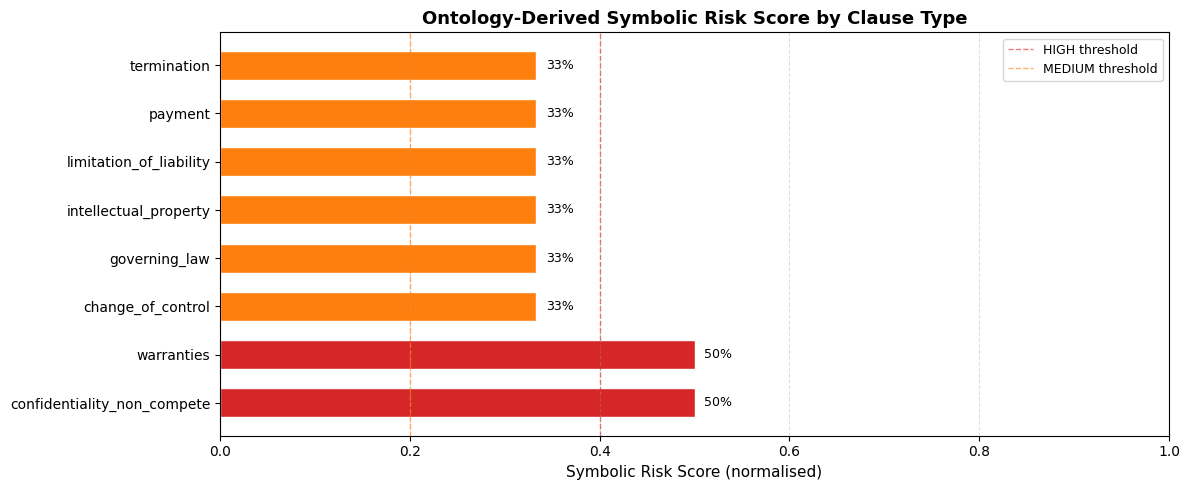

Risk score chart saved.


In [27]:
# %% [markdown]
# ## Cell 10 — Symbolic Risk Score Distribution

# %%
risk_summary = (
    df_enriched.groupby("clause_type")["symbolic_risk_score"]
    .first()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

colors = ["#d62728" if v >= 0.4 else "#ff7f0e" if v >= 0.2 else "#2ca02c"
          for v in risk_summary["symbolic_risk_score"]]

bars = ax.barh(
    risk_summary["clause_type"],
    risk_summary["symbolic_risk_score"],
    color=colors,
    edgecolor="white",
    height=0.6,
)

ax.set_xlabel("Symbolic Risk Score (normalised)", fontsize=11)
ax.set_title("Ontology-Derived Symbolic Risk Score by Clause Type", fontsize=13, fontweight="bold")
ax.set_xlim(0, 1)
ax.axvline(0.4, color="#d62728", linestyle="--", linewidth=1, alpha=0.6, label="HIGH threshold")
ax.axvline(0.2, color="#ff7f0e", linestyle="--", linewidth=1, alpha=0.6, label="MEDIUM threshold")
ax.legend(fontsize=9)
ax.grid(axis="x", linestyle="--", alpha=0.4)

for bar, val in zip(bars, risk_summary["symbolic_risk_score"]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.0%}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("symbolic_risk_scores.png", dpi=150, bbox_inches="tight")
plt.show()
print("Risk score chart saved.")

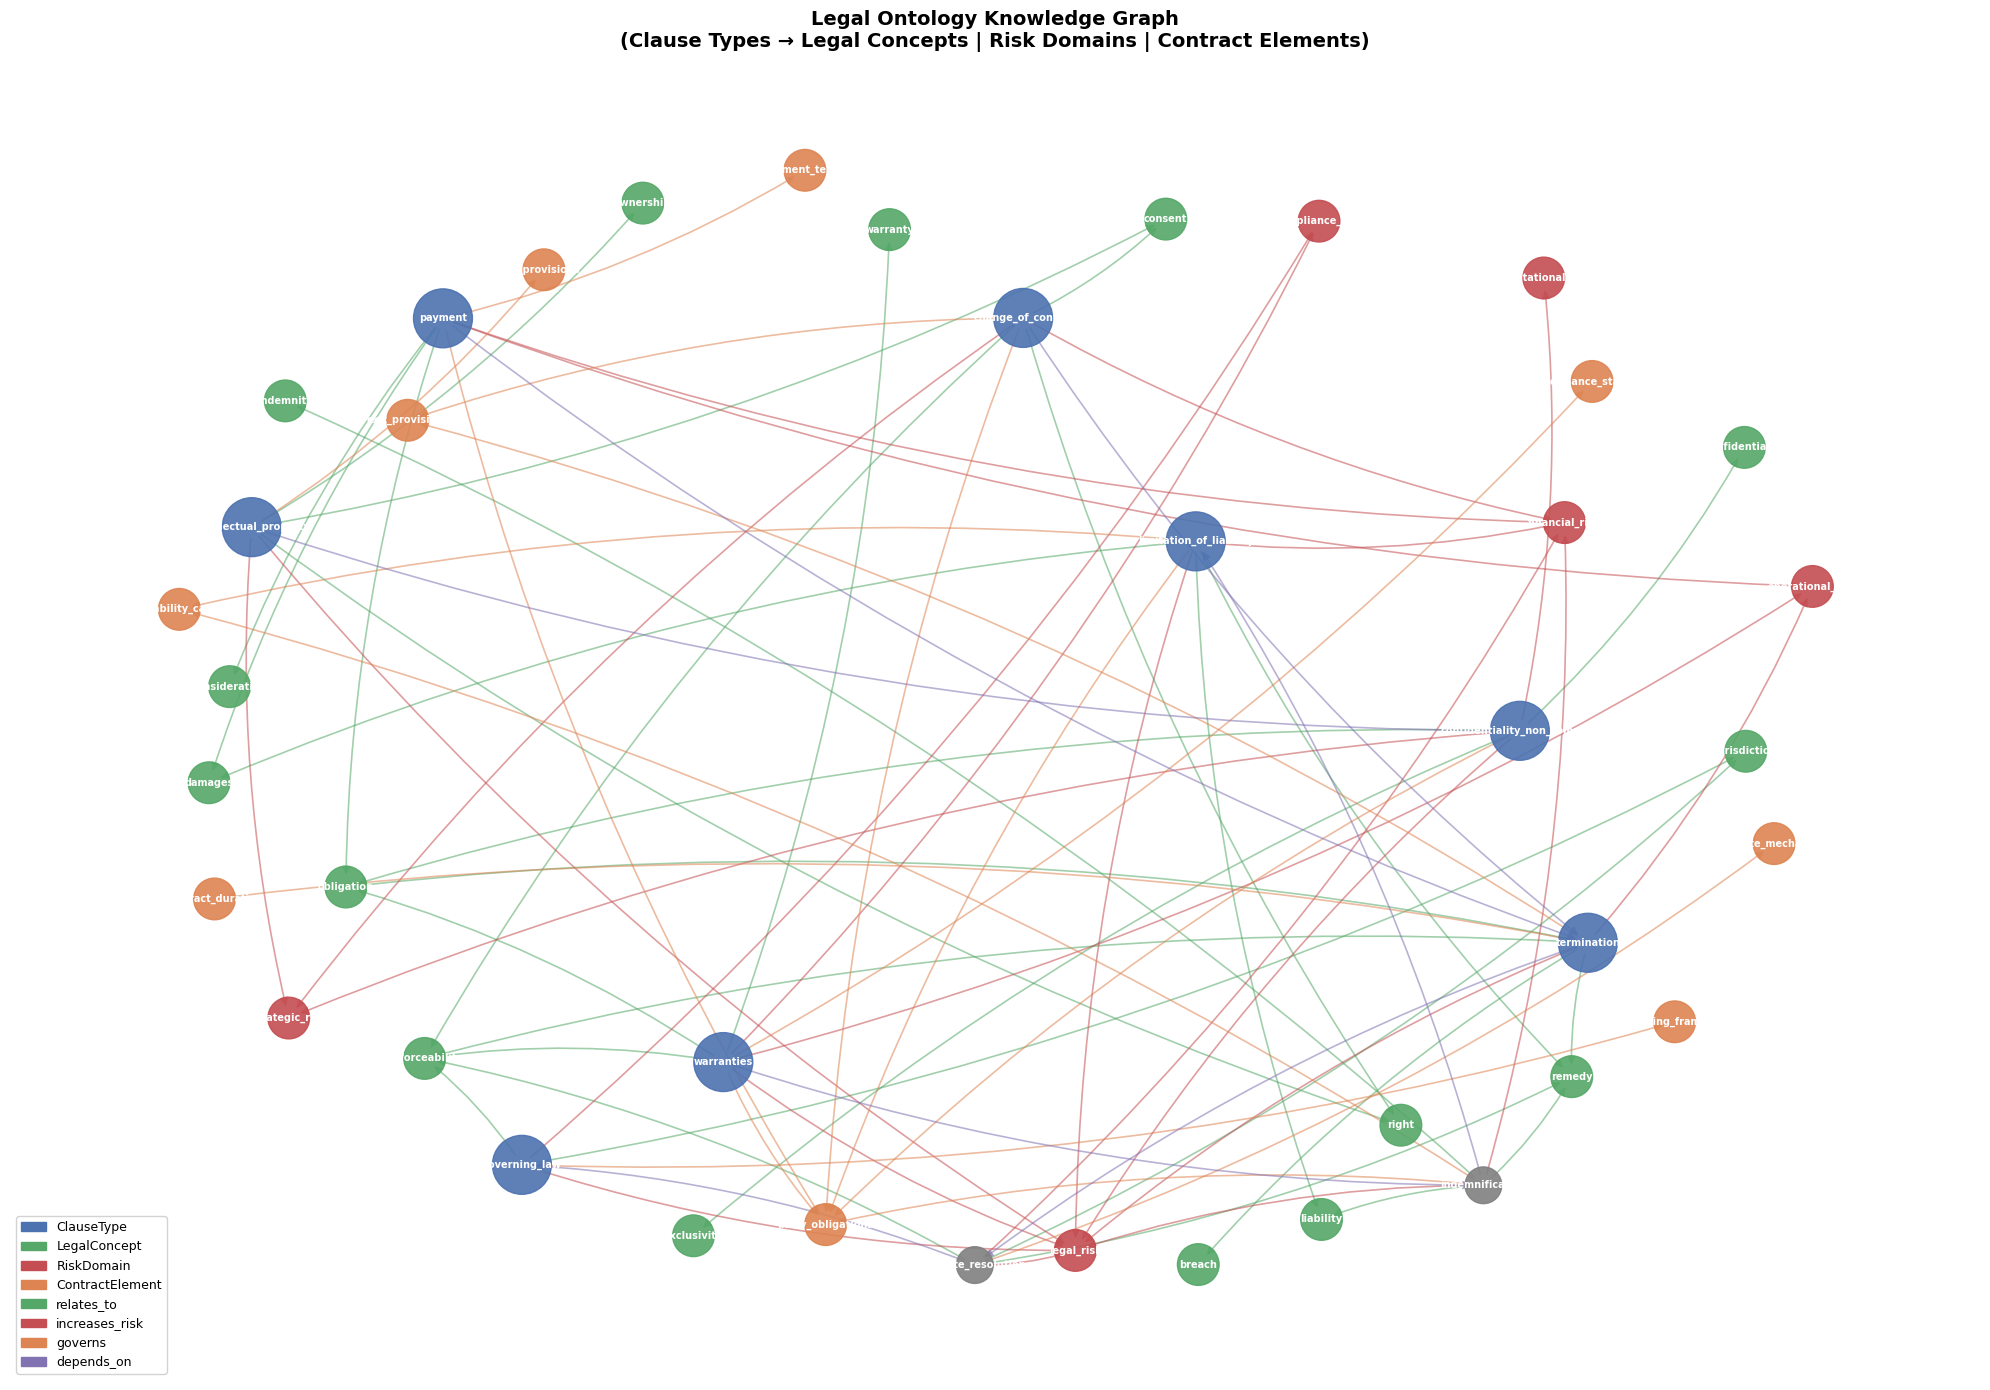

Full ontology graph saved.


In [34]:
# %% [markdown]
# ## Cell 11 — Full Ontology Graph Visualisation
#
# Colour-coded by node category. Layout: spring for global structure.

# %%
CATEGORY_COLORS = {
    "ClauseType":      "#4C72B0",
    "LegalConcept":    "#55A868",
    "RiskDomain":      "#C44E52",
    "ContractElement": "#DD8452",
}

CATEGORY_SIZES = {
    "ClauseType":      1800,
    "LegalConcept":    900,
    "RiskDomain":      900,
    "ContractElement": 900,
}

node_colors = [
    CATEGORY_COLORS.get(G.nodes[n].get("category", "Unknown"), "#808080")
    for n in G.nodes()
]
node_sizes = [
    CATEGORY_SIZES.get(G.nodes[n].get("category", "Unknown"), 700)
    for n in G.nodes()
]

pos = nx.spring_layout(G, seed=42, k=2.2)

fig, ax = plt.subplots(figsize=(20, 14))

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7, font_color="white", font_weight="bold", ax=ax)

edge_relation_colors = {
    "relates_to":     "#55A868",
    "increases_risk": "#C44E52",
    "governs":        "#DD8452",
    "depends_on":     "#8172B2",
}

for relation, color in edge_relation_colors.items():
    edges = [(u, v) for u, v, d in G.edges(data=True) if d["relation"] == relation]
    nx.draw_networkx_edges(
        G, pos, edgelist=edges,
        edge_color=color, alpha=0.55,
        arrows=True, arrowsize=12,
        width=1.2, ax=ax,
        connectionstyle="arc3,rad=0.08",
    )

legend_patches = [mpatches.Patch(color=c, label=cat) for cat, c in CATEGORY_COLORS.items()]
legend_edge    = [mpatches.Patch(color=c, label=rel) for rel, c in edge_relation_colors.items()]
ax.legend(handles=legend_patches + legend_edge, loc="lower left", fontsize=9, framealpha=0.85)

ax.set_title("Legal Ontology Knowledge Graph\n(Clause Types → Legal Concepts | Risk Domains | Contract Elements)",
             fontsize=14, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig("ontology_full_graph.png", dpi=150, bbox_inches="tight")
plt.show()
print("Full ontology graph saved.")

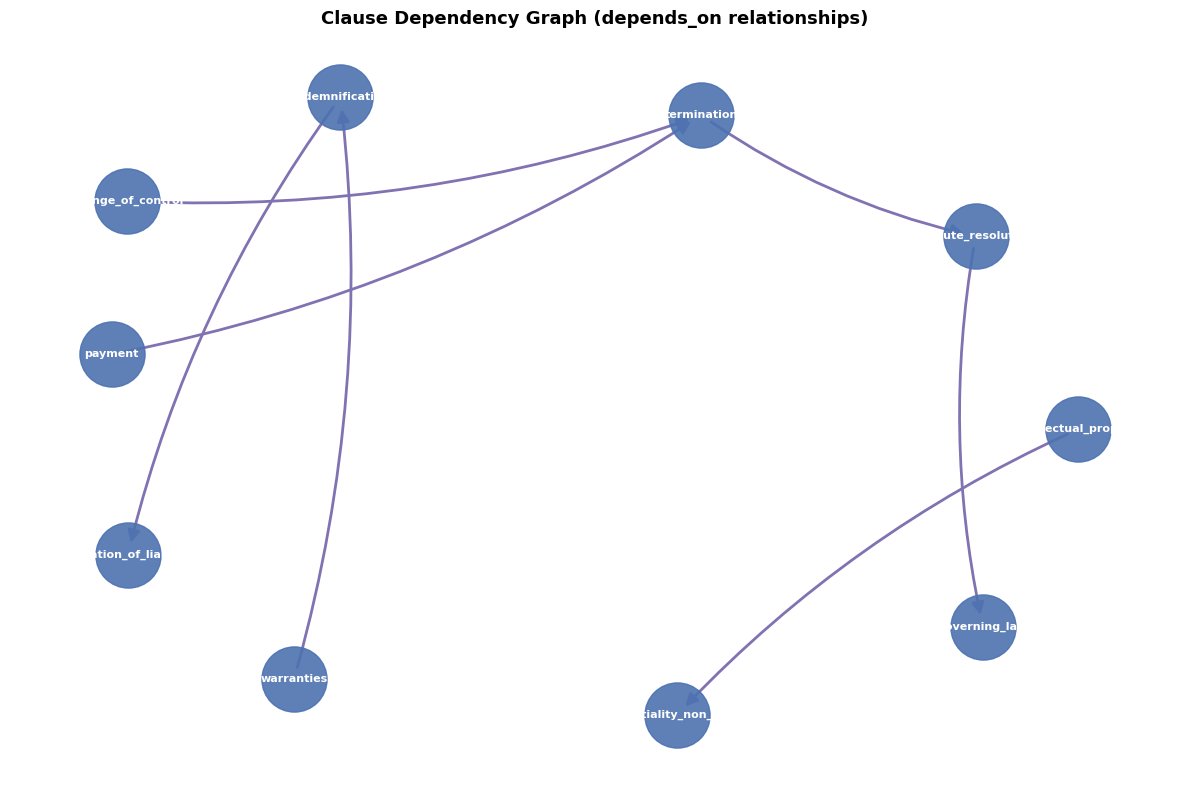

Dependency graph saved.


In [29]:
# %% [markdown]
# ## Cell 12 — Clause Dependency Subgraph
#
# Isolates only the depends_on edges to show clause interdependency structure.

# %%
dep_edges = [(u, v) for u, v, d in G.edges(data=True) if d["relation"] == "depends_on"]
dep_graph = nx.DiGraph()
dep_graph.add_edges_from(dep_edges)

pos_dep = nx.spring_layout(dep_graph, seed=7, k=2.5)

fig, ax = plt.subplots(figsize=(12, 8))

nx.draw_networkx_nodes(dep_graph, pos_dep, node_color="#4C72B0", node_size=2200, alpha=0.9, ax=ax)
nx.draw_networkx_labels(dep_graph, pos_dep, font_size=8, font_color="white", font_weight="bold", ax=ax)
nx.draw_networkx_edges(
    dep_graph, pos_dep,
    edge_color="#8172B2", arrows=True, arrowsize=18,
    width=2.0, ax=ax,
    connectionstyle="arc3,rad=0.1",
)

ax.set_title("Clause Dependency Graph (depends_on relationships)", fontsize=13, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig("clause_dependency_graph.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dependency graph saved.")

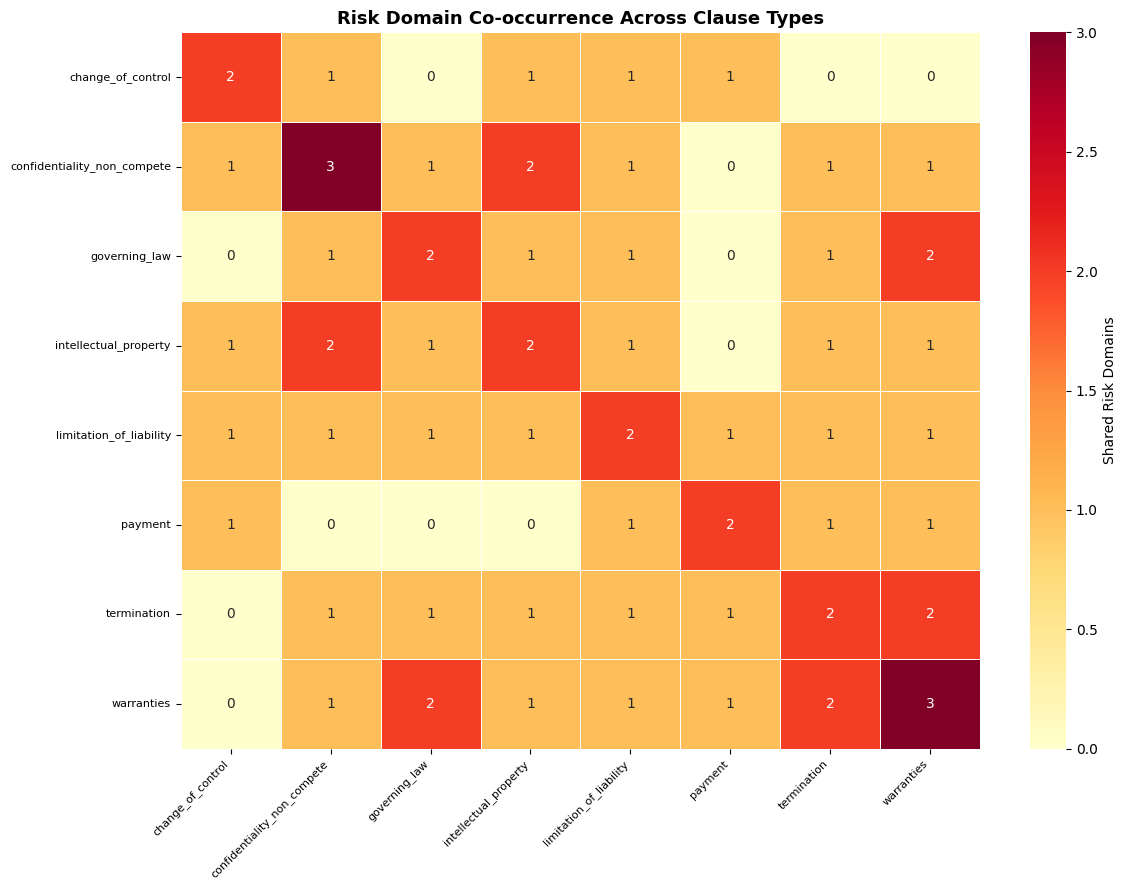

Risk co-occurrence heatmap saved.


In [30]:
# %% [markdown]
# ## Cell 13 — Risk Domain Co-occurrence Heatmap
#
# For each pair of clause types, shows how many risk domains they share —
# a measure of symbolic risk overlap.

# %%
risk_vectors = {
    ct: set(get_risk_domains(ct)) for ct in CLAUSE_TYPES
}

overlap_matrix = pd.DataFrame(0, index=CLAUSE_TYPES, columns=CLAUSE_TYPES, dtype=float)

for ct_a in CLAUSE_TYPES:
    for ct_b in CLAUSE_TYPES:
        shared = len(risk_vectors[ct_a] & risk_vectors[ct_b])
        overlap_matrix.loc[ct_a, ct_b] = shared

import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    overlap_matrix,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Shared Risk Domains"},
)
ax.set_title("Risk Domain Co-occurrence Across Clause Types", fontsize=13, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig("risk_cooccurrence_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Risk co-occurrence heatmap saved.")

In [37]:
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G, normalized=True)
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())

centrality_df = pd.DataFrame({
    "node": list(G.nodes()),
    "category": [G.nodes[n].get("category", "Unknown") for n in G.nodes()],
    "degree_centrality": [degree_centrality[n] for n in G.nodes()],
    "betweenness_centrality": [betweenness_centrality[n] for n in G.nodes()],
    "in_degree": [in_degree[n] for n in G.nodes()],
    "out_degree": [out_degree[n] for n in G.nodes()],
}).sort_values("betweenness_centrality", ascending=False).reset_index(drop=True)

print("Top 15 nodes by betweenness centrality (symbolic influence):")
print(centrality_df.head(15).to_string(index=False))

Top 15 nodes by betweenness centrality (symbolic influence):
                       node        category  degree_centrality  betweenness_centrality  in_degree  out_degree
                termination      ClauseType           0.282051                0.016194          2           9
         dispute_resolution         Unknown           0.205128                0.010796          1           7
              governing_law      ClauseType           0.153846                0.005398          1           5
            indemnification         Unknown           0.230769                0.004723          1           8
confidentiality_non_compete      ClauseType           0.205128                0.003374          1           7
    limitation_of_liability      ClauseType           0.205128                0.001350          1           7
          party_obligations ContractElement           0.153846                0.000000          6           0
                 legal_risk      RiskDomain           0.205

In [32]:
# %% [markdown]
# ## Cell 15 — Inference Demo: Neural → Symbolic Pipeline
#
# Simulates the full pipeline:
# Legal-BERT predicts → OntologyMapper enriches → symbolic explanation generated.
#
# Uses lightweight inference from saved NB01 artifacts.

# %%
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

LOAD_DIR   = "legal_bert_classifier"
MAX_LENGTH = 256

tokenizer_inf    = AutoTokenizer.from_pretrained(LOAD_DIR)
model_inf        = AutoModelForSequenceClassification.from_pretrained(LOAD_DIR)
label_classes_inf = np.load(os.path.join(LOAD_DIR, "label_classes.npy"), allow_pickle=True)
device_inf       = torch.device("cpu")
model_inf        = model_inf.to(device_inf)
model_inf.eval()

print("Legal-BERT artifacts loaded for inference demo.")


def predict_and_enrich(text: str) -> dict:
    """
    Full neural → symbolic pipeline for a single clause text.
    Returns classifier output enriched with ontology layer.
    """
    encoding = tokenizer_inf(
        text,
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )
    input_ids      = encoding["input_ids"].to(device_inf)
    attention_mask = encoding["attention_mask"].to(device_inf)

    with torch.no_grad():
        outputs = model_inf(input_ids=input_ids, attention_mask=attention_mask)
        probs   = torch.softmax(outputs.logits, dim=1).squeeze().cpu().numpy()

    predicted_idx   = int(np.argmax(probs))
    predicted_label = label_classes_inf[predicted_idx]
    confidence      = float(probs[predicted_idx])

    enriched = mapper.enrich(predicted_label, confidence)
    return enriched


# Demo clauses
DEMO_CLAUSES = [
    "Either party may terminate this agreement upon 30 days written notice.",
    "This agreement shall be governed by the laws of the State of New York.",
    "Each party shall indemnify and hold harmless the other from any claims arising.",
    "The licensee shall not reverse engineer or reproduce any proprietary software.",
]

print("\nNeural → Symbolic Pipeline Demo")
print("=" * 65)

for clause in DEMO_CLAUSES:
    result = predict_and_enrich(clause)
    print(f"\nClause:        {clause}")
    print(f"Predicted:     {result['clause_type']}  (confidence: {result['classifier_confidence']:.2%})")
    print(f"Risk Domains:  {result['risk_domains']}")
    print(f"Risk Score:    {result['symbolic_risk_score']:.0%}")
    print(f"Explanation:   {result['symbolic_explanation']}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Legal-BERT artifacts loaded for inference demo.

Neural → Symbolic Pipeline Demo

Clause:        Either party may terminate this agreement upon 30 days written notice.
Predicted:     termination  (confidence: 99.39%)
Risk Domains:  ['legal_risk', 'operational_risk']
Risk Score:    33%
Explanation:   This is a 'termination' clause. It activates the following legal concepts: obligation, breach, remedy, enforceability. Risk exposure: legal_risk, operational_risk (symbolic risk level: MEDIUM, score: 33%). This clause depends on: dispute_resolution.

Clause:        This agreement shall be governed by the laws of the State of New York.
Predicted:     governing_law  (confidence: 99.71%)
Risk Domains:  ['legal_risk', 'compliance_risk']
Risk Score:    33%
Explanation:   This is a 'governing_law' clause. It activates the following legal concepts: jurisdiction, enforceability. Risk exposure: legal_risk, compliance_risk (symbolic risk level: MEDIUM, score: 33%). This clause depends on: none.

Clau

In [38]:
# %% [markdown]
# ## Cell 16 — Export Ontology Artifacts
#
# Exports:
# - ontology_graph.graphml     → machine-readable graph format
# - ontology_nodes.csv         → node table with category metadata
# - ontology_edges.csv         → edge table with relation metadata
# - cuad_enriched_dataset.csv  → full enriched clause dataset
# - centrality_analysis.csv    → symbolic centrality scores

# %%
OUTPUT_DIR = "ontology_artifacts"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Debug: identify nodes missing category metadata ──────────────────────────
missing_category_nodes = [
    n for n in G.nodes()
    if "category" not in G.nodes[n]
]

if missing_category_nodes:
    print("WARNING: Nodes missing category metadata:")
    print(missing_category_nodes)

# ── GraphML export ───────────────────────────────────────────────────────────
nx.write_graphml(
    G,
    os.path.join(OUTPUT_DIR, "ontology_graph.graphml")
)

# ── Node table export ────────────────────────────────────────────────────────
nodes_df = pd.DataFrame([
    {
        "node": n,
        "category": G.nodes[n].get("category", "Unknown")
    }
    for n in G.nodes()
])

nodes_df.to_csv(
    os.path.join(OUTPUT_DIR, "ontology_nodes.csv"),
    index=False
)

# ── Edge table export ────────────────────────────────────────────────────────
edges_df = pd.DataFrame([
    {
        "source": u,
        "target": v,
        "relation": d.get("relation", "Unknown")
    }
    for u, v, d in G.edges(data=True)
])

edges_df.to_csv(
    os.path.join(OUTPUT_DIR, "ontology_edges.csv"),
    index=False
)

# ── Enriched dataset export ──────────────────────────────────────────────────
df_enriched.to_csv(
    os.path.join(OUTPUT_DIR, "cuad_enriched_dataset.csv"),
    index=False
)

# ── Centrality analysis export ───────────────────────────────────────────────
centrality_df.to_csv(
    os.path.join(OUTPUT_DIR, "centrality_analysis.csv"),
    index=False
)

# ── Export summary ───────────────────────────────────────────────────────────
print(f"\nAll artifacts exported successfully to: {OUTPUT_DIR}/")

print(f"\nExported files:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, f))
    print(f"  {f:<40s}  {size:>8,} bytes")

['indemnification', 'dispute_resolution']

All artifacts exported successfully to: ontology_artifacts/

Exported files:
  centrality_analysis.csv                      2,379 bytes
  cuad_enriched_dataset.csv                 4,513,934 bytes
  ontology_edges.csv                           3,175 bytes
  ontology_graph.graphml                      10,633 bytes
  ontology_nodes.csv                           1,097 bytes
